In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('placement (1).csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


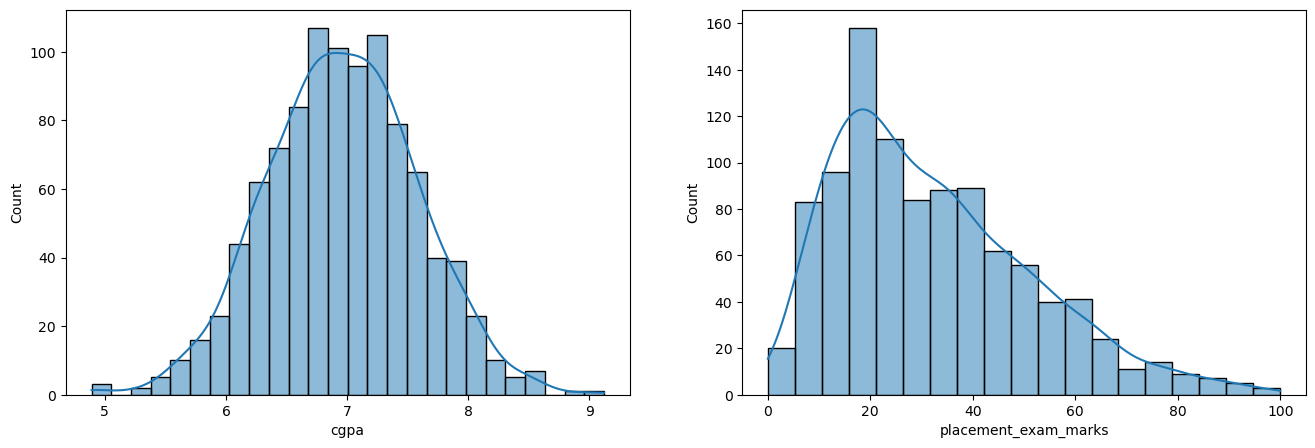

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(122)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.show()

In [7]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [8]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [9]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

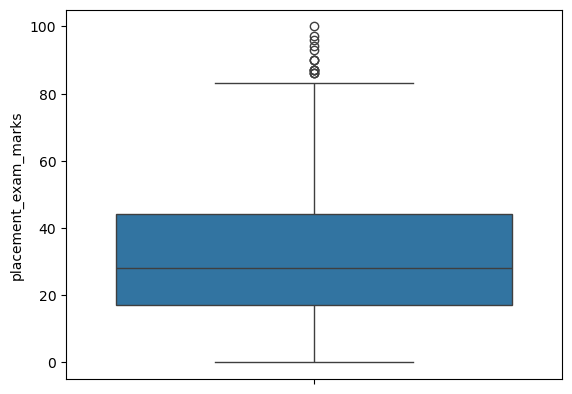

In [11]:
sns.boxplot(df['placement_exam_marks'])

In [13]:
# Finding the IQR
precentile_75=df['placement_exam_marks'].quantile(0.75)
precentile_25=df['placement_exam_marks'].quantile(0.25)

In [16]:
precentile_25,precentile_75

(np.float64(17.0), np.float64(44.0))

In [17]:
iqr=precentile_75-precentile_25

In [18]:
iqr

np.float64(27.0)

In [19]:
upper_limit=precentile_75+1.5*iqr
lower_limit=precentile_25-1.5*iqr

In [22]:
print('upper_limit',upper_limit)
print('lower_limit',lower_limit)

upper_limit 84.5
lower_limit -23.5


<h2></b>finding outliyer</h2></b>

In [32]:
df[df['placement_exam_marks']> upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [33]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


<h2></b>trimming</h2></b>

In [37]:
new_df=df[df['placement_exam_marks']<upper_limit]

In [38]:
new_df.shape

(985, 3)

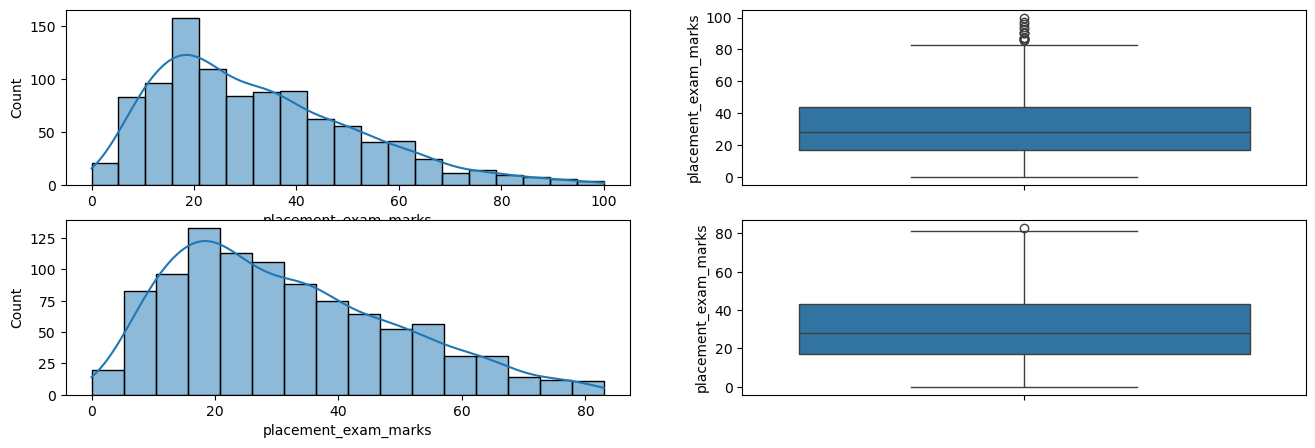

In [42]:
plt.figure(figsize=(16,5))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()


<h2></b>capping<b></h2>

In [52]:
new_df_cop=df.copy()

In [53]:
new_df_cop=pd.DataFrame(new_df_cop)

In [54]:
new_df_cop['placement_exam_marks']=np.where(new_df_cop['placement_exam_marks']>upper_limit,
                          upper_limit,
            np.where(new_df_cop['placement_exam_marks']<lower_limit,
                     lower_limit,
                     new_df_cop['placement_exam_marks']


                    )
                   )  

In [55]:
new_df_cop.shape

(1000, 3)

In [49]:
type(new_df_cop)

numpy.ndarray

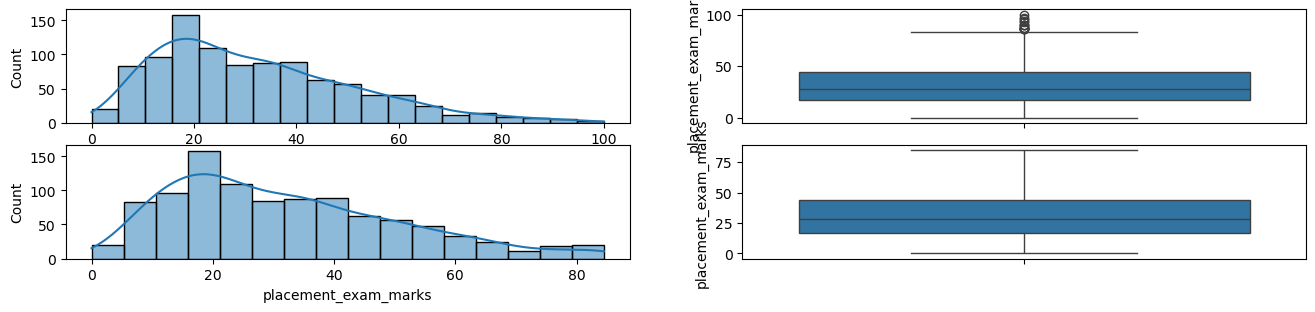

In [60]:
plt.figure(figsize=(16,5))
plt.subplot(321)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(322)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(323)
sns.histplot(new_df_cop['placement_exam_marks'],kde=True)

plt.subplot(324)
sns.boxplot(new_df_cop['placement_exam_marks'])

plt.show()